In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
!pip install torchsummary

In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False
)

trainset = torch.utils.data.Subset(trainset, range(10000))
testset = torch.utils.data.Subset(testset, range(2000))

100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s]


In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            # Corrected in_features from 128*4*4 to 64*8*8
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from torchsummary import summary

summary(model, (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 32, 32, 32]           9,248
       BatchNorm2d-5           [-1, 32, 32, 32]              64
              ReLU-6           [-1, 32, 32, 32]               0
         MaxPool2d-7           [-1, 32, 16, 16]               0
            Conv2d-8           [-1, 64, 16, 16]          18,496
       BatchNorm2d-9           [-1, 64, 16, 16]             128
             ReLU-10           [-1, 64, 16, 16]               0
           Conv2d-11           [-1, 64, 16, 16]          36,928
      BatchNorm2d-12           [-1, 64, 16, 16]             128
             ReLU-13           [-1, 64, 16, 16]               0
        MaxPool2d-14             [-1, 6

Epoch 1 Training Accuracy: 34.02% Loss: 1.776
Epoch 1 Test Accuracy: 43.30%
Epoch 2 Training Accuracy: 48.10% Loss: 1.411
Epoch 2 Test Accuracy: 53.26%
Epoch 3 Training Accuracy: 54.61% Loss: 1.257
Epoch 3 Test Accuracy: 57.95%
Epoch 4 Training Accuracy: 58.10% Loss: 1.170
Epoch 4 Test Accuracy: 59.26%
Epoch 5 Training Accuracy: 60.38% Loss: 1.109
Epoch 5 Test Accuracy: 61.14%
Epoch 6 Training Accuracy: 62.25% Loss: 1.062
Epoch 6 Test Accuracy: 62.44%
Epoch 7 Training Accuracy: 63.92% Loss: 1.022
Epoch 7 Test Accuracy: 65.63%
Epoch 8 Training Accuracy: 64.93% Loss: 0.991
Epoch 8 Test Accuracy: 65.49%
Epoch 9 Training Accuracy: 65.99% Loss: 0.966
Epoch 9 Test Accuracy: 65.49%
Epoch 10 Training Accuracy: 66.75% Loss: 0.946
Epoch 10 Test Accuracy: 66.36%
Epoch 11 Training Accuracy: 67.71% Loss: 0.919
Epoch 11 Test Accuracy: 67.33%
Epoch 12 Training Accuracy: 68.60% Loss: 0.896
Epoch 12 Test Accuracy: 68.15%
Epoch 13 Training Accuracy: 69.29% Loss: 0.879
Epoch 13 Test Accuracy: 68.00%
Epoc

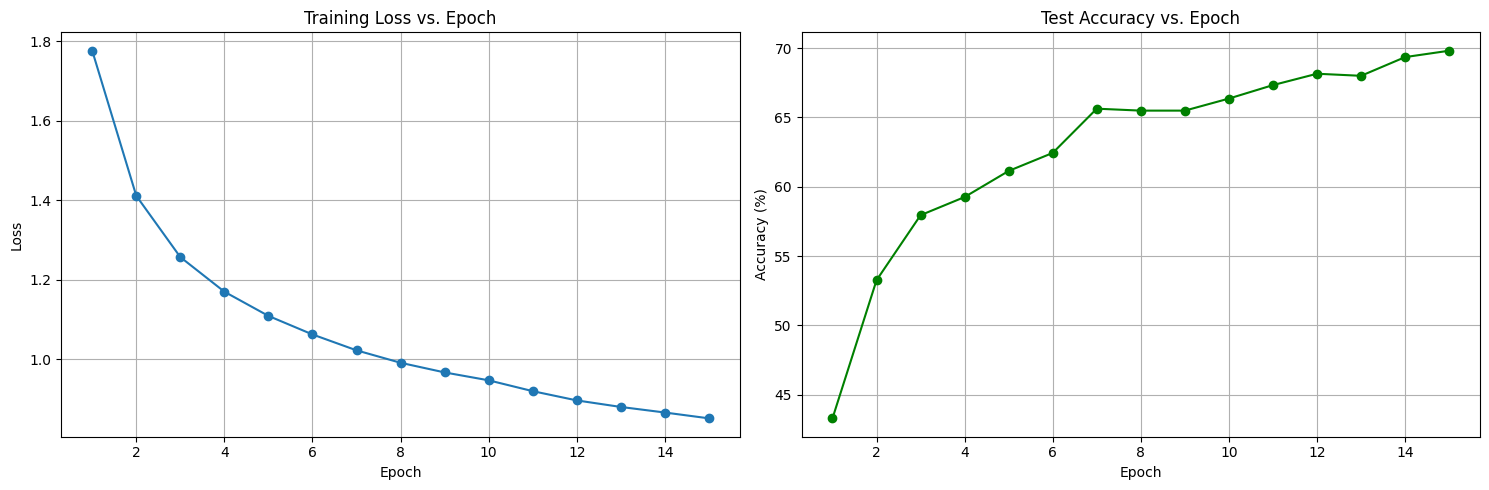

In [ ]:
import matplotlib.pyplot as plt

epochs = 15

train_losses = []
train_accuracies = [] # New list to store training accuracies
test_accuracies = []

for epoch in range(epochs):

    correct_train = 0
    total_train = 0
    running_loss = 0.0

    for i, (images, labels) in enumerate(trainloader):

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted_train = torch.max(outputs.data,1)
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    train_accuracy = 100 * correct_train / total_train
    train_accuracies.append(train_accuracy) # Store training accuracy

    print(f"Epoch {epoch+1} Training Accuracy: {train_accuracy:.2f}% Loss: {epoch_loss:.3f}")

    # Evaluate on test set for test accuracy per epoch
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted_test = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (predicted_test == labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    test_accuracies.append(test_accuracy)
    print(f"Epoch {epoch+1} Test Accuracy: {test_accuracy:.2f}%")

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss vs. Epoch
ax1.plot(range(1, epochs + 1), train_losses, marker='o')
ax1.set_title('Training Loss vs. Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

# Plot Accuracy vs. Epoch
ax2.plot(range(1, epochs + 1), train_accuracies, marker='o', label='Training Accuracy') # Plot training accuracy
ax2.plot(range(1, epochs + 1), test_accuracies, marker='o', color='green', label='Test Accuracy') # Plot test accuracy
ax2.set_title('Accuracy vs. Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in testloader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100*correct/total)

Test Accuracy: 71.66
